## Carga de Datos

In [1]:
# 1. Manipulación y Procesamiento de Datos
import pandas as pd
import numpy as np
from scipy import stats
import os

# 2. Preprocesamiento y Transformación de Variables (ML)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 3. Modelado y Algoritmos (Machine Learning y Regresión)
from sklearn.ensemble import IsolationForest     
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
# Importación de los 4 modelos
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor  
from sklearn.pipeline import Pipeline

# 4. Visualización de Datos Estática (Informes y Documentación)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 5. Visualización de Datos Interactiva y Modelos 3D (Presentación en clase)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Configuración por defecto para que Plotly abra los gráficos 3D en tu navegador
pio.renderers.default = "browser"

# 1. Carga del dataset
df = pd.read_csv(r'data\train.csv')
# 2. Visualizar las primeras 5 filas
print("--- Primeras filas del dataset ---")
display(df.head())

# 3. Inspección de tipos de datos y valores no nulos
print("\n--- Información general del DataFrame ---")
df.info()

--- Primeras filas del dataset ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

## Creación del Directorio de Utilidades (`data/utiles/`)

### Carpeta Utiles

In [2]:
# Definimos la ruta de la nueva carpeta para archivos útiles
carpeta_utiles = os.path.join('data', 'utiles')

# Creamos la carpeta 'data/utiles' si aún no existe en el proyecto
os.makedirs(carpeta_utiles, exist_ok=True)

# Definimos el nombre y la ruta del archivo que quieras guardar allí
# (Cambia 'mis_utiles.csv' por el nombre que prefieras para tu archivo)
ruta_archivo_utiles = os.path.join(carpeta_utiles, 'mis_utiles.csv')

# Guardamos el DataFrame (asegúrate de cambiar 'df_clean' por el objeto que quieras salvar)
# df_clean.to_csv(ruta_archivo_utiles, index=False)

print(f"📁 Carpeta de utilidades lista y verificada en: {carpeta_utiles}")
print(f"📍 Listo para guardar archivos en: {ruta_archivo_utiles}")

📁 Carpeta de utilidades lista y verificada en: data\utiles
📍 Listo para guardar archivos en: data\utiles\mis_utiles.csv


## Auditoría de Calidad de Datos: Integridad y Estructura de las Variables

Antes de aplicar cualquier transformación o entrenar los modelos, realizamos un diagnóstico exhaustivo en dos frentes críticos: la detección de datos faltantes y la consistencia de nuestras variables categóricas.

### Diagnóstico de Valores Faltantes (Missing Values)
Calculamos el recuento absoluto y el peso relativo de los nulos para diseñar las estrategias de imputación óptimas (media, mediana o moda) y asegurar que el modelo no reciba información incompleta.



In [3]:
# 1. Hacemos la copia inicial para empezar la limpieza
df_clean = df.copy()

# =====================================================================
# 2. ELIMINACIÓN DE OUTLIERS (Primero, para no sesgar las estadísticas)
# =====================================================================
# Filtramos el dataset para quedarnos SOLO con las casas que tengan 
# menos de 4000 pies cuadrados de superficie habitable.
df_clean = df_clean[df_clean['GrLivArea'] < 4000]


# =====================================================================
# 3. IMPUTACIÓN DE VALORES NULOS (Basada en los datos ya filtrados)
# =====================================================================
# Variables categóricas que significan 'None' (Ausencia del elemento)
categoricas_ninguno = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
    'MasVnrType'
]

for col in categoricas_ninguno:
    df_clean[col] = df_clean[col].fillna('None')

# Variables numéricas específicas
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

# Imputación por mediana (calculada sin el sesgo de los outliers eliminados)
mediana_fachada = df_clean['LotFrontage'].median()
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(mediana_fachada)

# Imputación por moda
moda_electrica = df_clean['Electrical'].mode()[0]
df_clean['Electrical'] = df_clean['Electrical'].fillna(moda_electrica)


# =====================================================================
# 4. GUARDADO EN LA RUTA OPTIMIZADA
# =====================================================================
# Definimos la ruta de la carpeta anidada ('data/utiles/clean_data')
carpeta_destino = os.path.join('data', 'utiles', 'clean_data')

# Creamos toda la estructura de carpetas si no existe todavía
os.makedirs(carpeta_destino, exist_ok=True)

# Definimos la ruta completa incluyendo el nombre del archivo final
ruta_archivo_final = os.path.join(carpeta_destino, 'clean_train.csv')

# Guardamos EXCLUSIVAMENTE el DataFrame limpio (df_clean)
df_clean.to_csv(ruta_archivo_final, index=False)


# =====================================================================
# 5. COMPROBACIÓN FINAL
# =====================================================================
nulos_restantes = df_clean.isnull().sum().sum()
total_filas_actuales = df_clean.shape[0]

print(f"✅ ¡Limpieza y guardado completados con éxito!")
print(f"📍 Archivo exportado a: {ruta_archivo_final}")
print(f"❌ Valores nulos restantes en el dataset: {nulos_restantes}")
print(f"🏠 Casas restantes en el dataset (tras eliminar outliers): {total_filas_actuales}")

✅ ¡Limpieza y guardado completados con éxito!
📍 Archivo exportado a: data\utiles\clean_data\clean_train.csv
❌ Valores nulos restantes en el dataset: 0
🏠 Casas restantes en el dataset (tras eliminar outliers): 1456


### Inspección de Consistencia Categórica (Valores Únicos)
Auditamos las respuestas y etiquetas reales de las variables cualitativas de la base de datos (como la zonificación o el tipo de calle). Esto nos permite verificar que no existan errores de escritura, duplicados por mayúsculas o categorías irrelevantes antes de aplicar el proceso de *Encoding* (`OneHotEncoder`) en el pipeline definitivo.

In [4]:
# Comprobar los valores únicos exactos de las columnas categóricas reales
print("Valores únicos en 'MSZoning' (Zonificación):")
print(df['MSZoning'].unique())

print("\nValores únicos en 'Street' (Tipo de calle):")
print(df['Street'].unique())

print("\nValores únicos en 'LotShape' (Forma del terreno):")
print(df['LotShape'].unique())

Valores únicos en 'MSZoning' (Zonificación):
<ArrowStringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Valores únicos en 'Street' (Tipo de calle):
<ArrowStringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Valores únicos en 'LotShape' (Forma del terreno):
<ArrowStringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str


In [5]:
# Variables categóricas clave del nuevo dataset de viviendas
print("Valores únicos en 'MSZoning' (Clasificación de la zona):")
print(df['MSZoning'].unique())

print("\nValores únicos en 'Neighborhood' (Barrios disponibles):")
print(df['Neighborhood'].unique())

print("\nValores únicos en 'SaleCondition' (Condición de la venta):")
print(df['SaleCondition'].unique())

print("\nValores únicos en 'KitchenQual' (Calidad de la cocina):")
print(df['KitchenQual'].unique())

Valores únicos en 'MSZoning' (Clasificación de la zona):
<ArrowStringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Valores únicos en 'Neighborhood' (Barrios disponibles):
<ArrowStringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Valores únicos en 'SaleCondition' (Condición de la venta):
<ArrowStringArray>
['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca', 'Family']
Length: 6, dtype: str

Valores únicos en 'KitchenQual' (Calidad de la cocina):
<ArrowStringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str


In [6]:
# Muestra un resumen técnico del DataFrame
df_clean.info()

# Muestra la cantidad de filas y columnas (ej. (1460, 22))
print("Dimensiones del DataFrame:", df_clean.shape)

<class 'pandas.DataFrame'>
Index: 1456 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1456 non-null   int64  
 1   MSSubClass     1456 non-null   int64  
 2   MSZoning       1456 non-null   str    
 3   LotFrontage    1456 non-null   float64
 4   LotArea        1456 non-null   int64  
 5   Street         1456 non-null   str    
 6   Alley          1456 non-null   str    
 7   LotShape       1456 non-null   str    
 8   LandContour    1456 non-null   str    
 9   Utilities      1456 non-null   str    
 10  LotConfig      1456 non-null   str    
 11  LandSlope      1456 non-null   str    
 12  Neighborhood   1456 non-null   str    
 13  Condition1     1456 non-null   str    
 14  Condition2     1456 non-null   str    
 15  BldgType       1456 non-null   str    
 16  HouseStyle     1456 non-null   str    
 17  OverallQual    1456 non-null   int64  
 18  OverallCond    1456 non-

### Carpeta Outliers

In [7]:
# 1. Definimos la ruta de la carpeta anidada de forma segura
carpeta_destino = os.path.join('data', 'utiles', 'outliers')

# 2. Creamos la carpeta 'outliers' (y las anteriores si no existieran)
os.makedirs(carpeta_destino, exist_ok=True)

# 3. Definimos el nombre y la ruta final del archivo
ruta_outliers = os.path.join(carpeta_destino, 'data_con_outliers_marcados.csv')

# 4. Guardamos el DataFrame en la nueva ubicación
df_clean.to_csv(ruta_outliers, index=False)

print(f"💾 Archivo final con marcas guardado exitosamente en: {ruta_outliers}")

#5. 

df_outliers = pd.read_csv(ruta_outliers)

💾 Archivo final con marcas guardado exitosamente en: data\utiles\outliers\data_con_outliers_marcados.csv


C:\Users\felix\AppData\Local\Temp\ipykernel_26188\438264878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='OverallQual', y='SalePrice', data=df_outliers, palette='Blues')


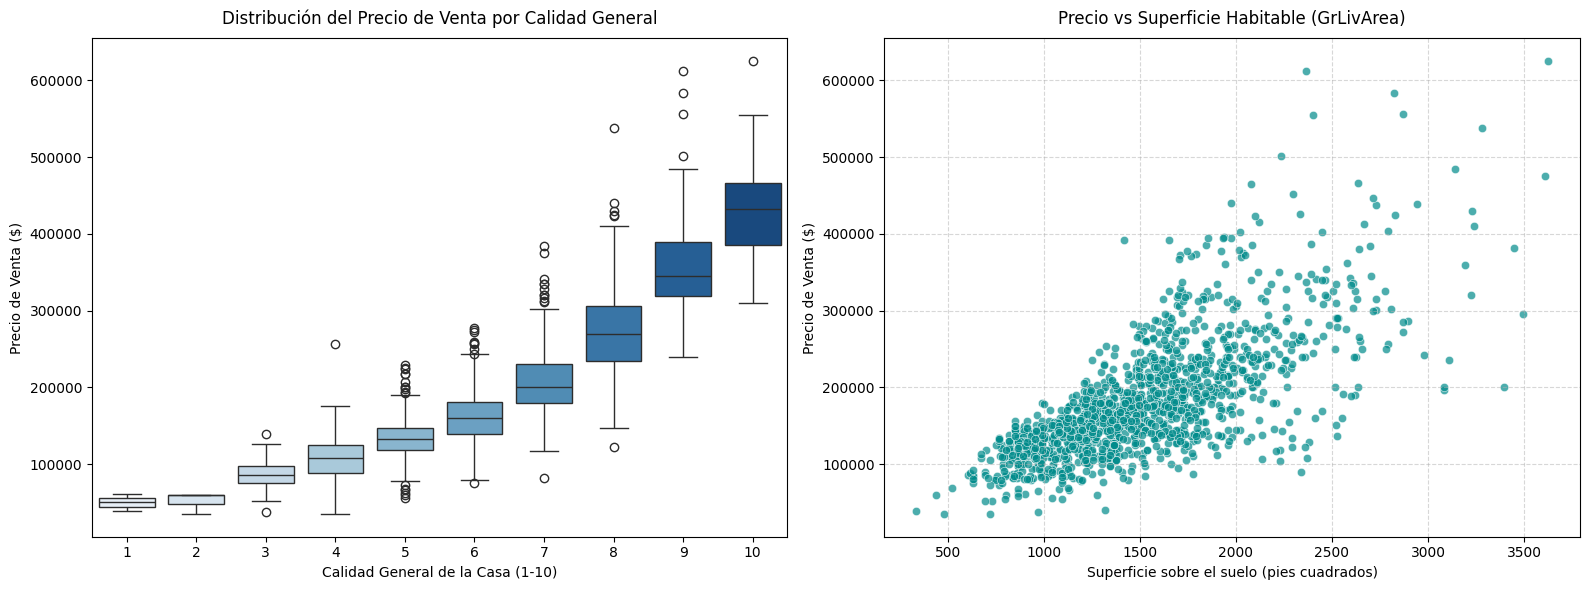

In [8]:
# Creamos un lienzo con dos subgráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de caja (Izquierda): Precio vs Calidad General
sns.boxplot(ax=axes[0], x='OverallQual', y='SalePrice', data=df_outliers, palette='Blues')
axes[0].set_title('Distribución del Precio de Venta por Calidad General', fontsize=12, pad=10)
axes[0].set_xlabel('Calidad General de la Casa (1-10)')
axes[0].set_ylabel('Precio de Venta ($)')

# 2. Gráfico de dispersión (Derecha): Precio vs Superficie Habitable
sns.scatterplot(ax=axes[1], x=df_outliers["GrLivArea"], y=df_outliers["SalePrice"], alpha=0.7, color="darkcyan")
axes[1].set_title("Precio vs Superficie Habitable (GrLivArea)", fontsize=12, pad=10)
axes[1].set_xlabel("Superficie sobre el suelo (pies cuadrados)")
axes[1].set_ylabel("Precio de Venta ($)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

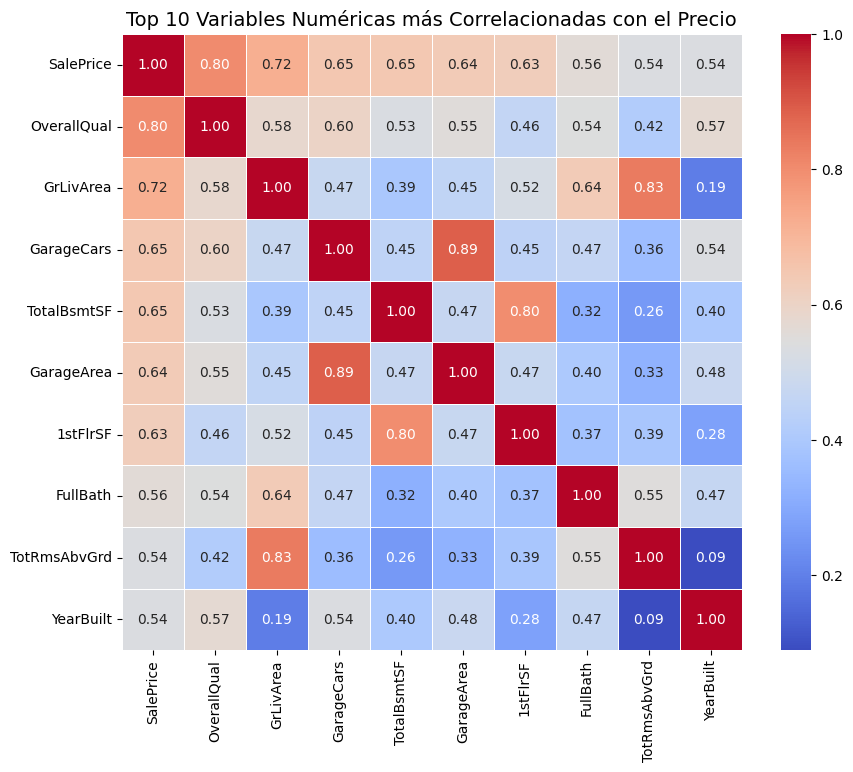

In [9]:
#Filtramos solo columnas numericas(ya que la correlacion solo funciona con numeros)
df_numerico = df_outliers.select_dtypes(include=[np.number])

#Calcular matriz de correlacion
matriz_corr = df_numerico.corr()

#Extraer la correlacion de todas las variables con respecto a SalePrice
#Se ordenan de mayor a menos y nos quedamos con las 10 primeras
top_10_variables = matriz_corr["SalePrice"].sort_values(ascending=False).index[:10]

#Dibujar heatmap en base al top 10
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_outliers[top_10_variables].corr(), 
    annot=True,          # Añade el número de correlación dentro de cada cuadro
    cmap="coolwarm",     # Escala de color (azul=negativo, rojo=positivo)
    fmt=".2f",           # Limita a 2 decimales
    linewidths=0.5       # Añade una línea fina de separación entre cuadros
)

plt.title("Top 10 Variables Numéricas más Correlacionadas con el Precio", fontsize=14)
plt.show()

## Análisis Univariado

In [10]:
df_clean.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.00000,1456.000000,1456.000000,1456.000000,...,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,729.967033,56.888736,69.570055,10448.784341,6.088599,5.576236,1971.18544,1984.819368,101.526786,436.991071,...,93.833791,46.221154,22.014423,3.418956,15.102335,2.055632,43.608516,6.326236,2007.817308,180151.233516
std,421.722909,42.358363,20.903753,9860.763449,1.369669,1.113966,30.20159,20.652143,177.011773,430.255052,...,125.192349,65.352424,61.192248,29.357056,55.828405,35.383772,496.799265,2.698356,1.329394,76696.592530
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.00000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,364.750000,20.000000,60.000000,7538.750000,5.000000,5.000000,1954.00000,1966.750000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129900.000000
50%,730.500000,50.000000,69.000000,9468.500000,6.000000,5.000000,1972.00000,1993.500000,0.000000,381.000000,...,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1094.250000,70.000000,79.000000,11588.000000,7.000000,6.000000,2000.00000,2004.000000,163.250000,706.500000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.00000,2010.000000,1600.000000,2188.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,625000.000000


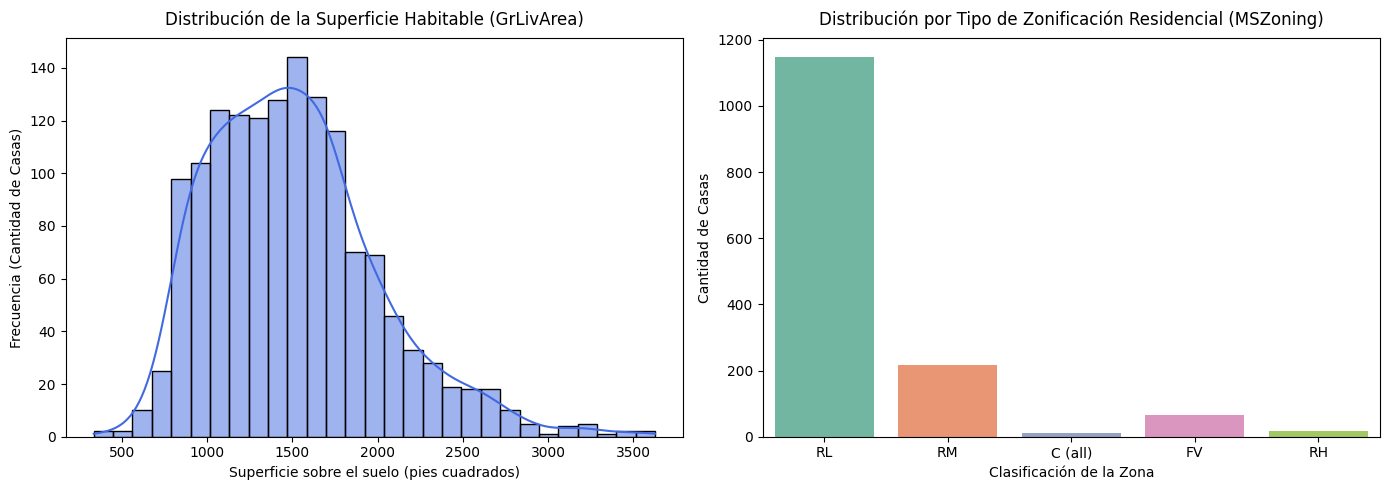

In [11]:
# Configuramos el lienzo para ver dos gráficos a la vez
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico univariado para una variable NUMÉRICA (Distribución del tamaño de las casas)
sns.histplot(data=df_clean, x='GrLivArea', kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribución de la Superficie Habitable (GrLivArea)', fontsize=12, pad=10)
axes[0].set_xlabel('Superficie sobre el suelo (pies cuadrados)')
axes[0].set_ylabel('Frecuencia (Cantidad de Casas)')

# 2. Gráfico univariado para conteo de variables CATEGÓRICAS (Tipo de Zonificación)
# Usamos df_clean y añadimos hue=None para evitar advertencias de paletas en Seaborn
sns.countplot(data=df_clean, x='MSZoning', ax=axes[1], palette='Set2', hue='MSZoning', legend=False)
axes[1].set_title('Distribución por Tipo de Zonificación Residencial (MSZoning)', fontsize=12, pad=10)
axes[1].set_xlabel('Clasificación de la Zona')
axes[1].set_ylabel('Cantidad de Casas')

plt.tight_layout()
plt.show()

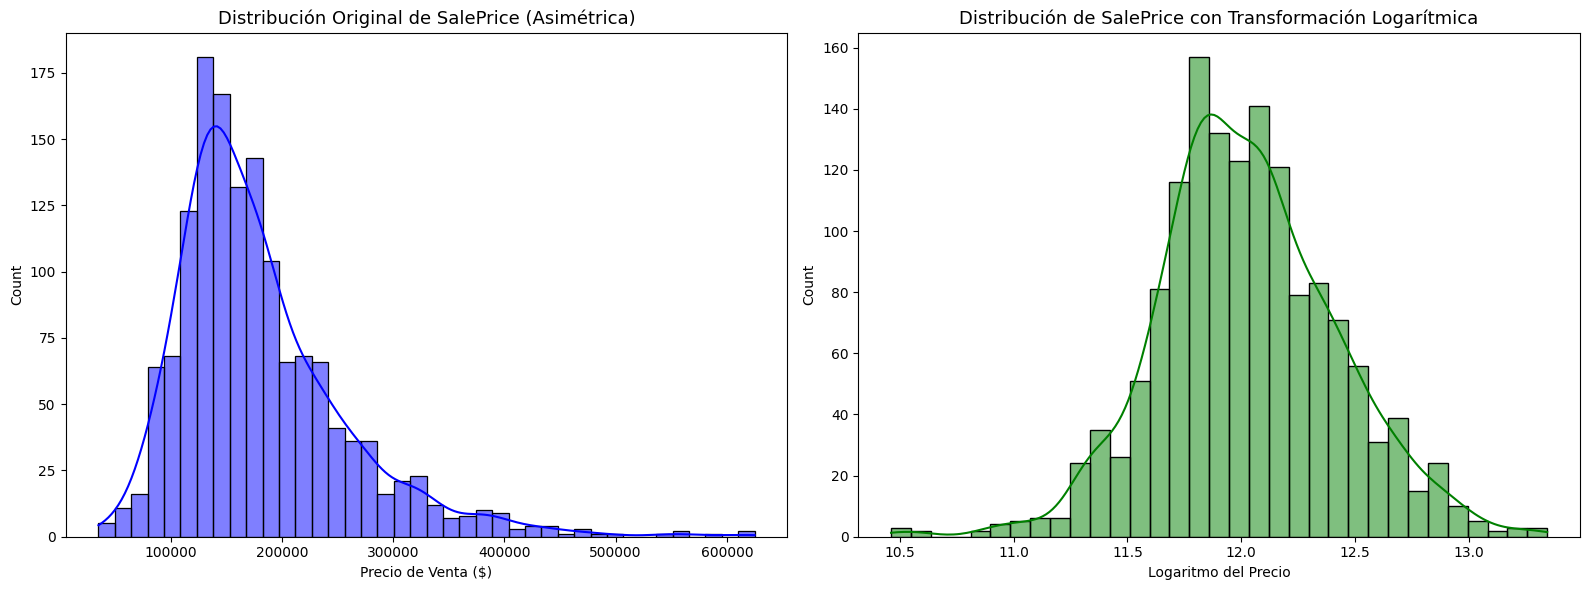

In [12]:
#Aplicamos transformacion logaritmica
df_clean["SalePrice_Log"] = np.log1p(df_clean["SalePrice"])

#creamos un lienzo para comparar ambas distribuciones
fig,axes = plt.subplots(1,2, figsize = (16,6))

# Gráfica Izquierda: Distribución Original (Sesgada)
sns.histplot(ax=axes[0], data=df_clean, x="SalePrice", kde=True, color="blue")
axes[0].set_title("Distribución Original de SalePrice (Asimétrica)", fontsize=13)
axes[0].set_xlabel("Precio de Venta ($)")

# Gráfica Derecha: Nueva Distribución Logarítmica (Normalizada)
sns.histplot(ax=axes[1], data=df_clean, x="SalePrice_Log", kde=True, color="green")
axes[1].set_title("Distribución de SalePrice con Transformación Logarítmica", fontsize=13)
axes[1].set_xlabel("Logaritmo del Precio")

plt.tight_layout()
plt.show()

# Conclusiones del Análisis Exploratorio de Datos (EDA)

Tras la inspección visual, estadística y el análisis exploratorio de las variables clave del dataset de viviendas, se han extraído conclusiones fundamentales que guiarán la fase de preprocesamiento, ingeniería de características y el posterior entrenamiento de los modelos de regresión avanzados:

## 1. Comportamiento y Distribución de la Variable Objetivo (`SalePrice`)
El análisis del precio de venta (`SalePrice`) revela una asimetría positiva común en los mercados inmobiliarios, donde la mayoría de las viviendas se concentran en un rango medio-bajo, pero existe una cola alargada hacia la derecha que representa propiedades de lujo de alto valor.
* **Implicación analítica:** Para algoritmos de regresión lineal o basados en distancias, esta asimetría puede distorsionar las predicciones en los extremos. Será fundamental aplicar una transformación matemática (como el escalado logarítmico o Box-Cox) durante el preprocesamiento para aproximar la variable a una **Distribución Normal (Gaussiana)**. Esto estabilizará la varianza del modelo y mejorará significativamente la métrica del error absoluto medio (MAE) y el $R^2$.

## 2. Segmentación del Mercado y Clasificación por Zonas (`MSZoning`)
El comportamiento de las variables categóricas de ubicación, especialmente la zonificación (`MSZoning`), demuestra un claro predominio de la categoría residencial de baja densidad (**RL**), seguida por la residencial de densidad media (**RM**), dejando una presencia minoritaria a las zonas comerciales (**C (all)**), industriales o residenciales de alta densidad.
* **Implicación analítica:** El dataset cuenta con un volumen robusto de registros para los segmentos más comunes del mercado masivo. Para que el algoritmo procese correctamente el impacto económico de cada zona sin sesgarse hacia la clase dominante (RL), se ejecutará de forma dinámica una transformación mediante **One-Hot Encoding** en las variables categóricas detectadas. Esto permitirá capturar de forma limpia el valor diferencial que aporta cada barrio (`Neighborhood`) o tipo de calle (`Street`) al valor final del inmueble.

## 3. Diagnóstico de Datos Faltantes y Estrategia de Imputación
La inspección detallada de la integridad de los datos reveló escenarios muy dispares: variables con nulos masivos o estructurales como la calidad de la piscina (`PoolQC` con 99.52%) o elementos misceláneos (`MiscFeature` con 96.30%), frente a variables críticas con pérdidas controladas como el frente del lote (`LotFrontage` con 17.74%).
* **Implicación analítica:** No se puede aplicar una eliminación directa de filas ya que comprometería el volumen de entrenamiento. La estrategia validada en el código consistirá en una **imputación híbrida y robusta**:
  * Para variables numéricas (como años de construcción o áreas), se empleará la **mediana** para evitar que los valores extremos distorsionen la tendencia central.
  * Para variables categóricas (como calidades de sótano o acabados), se utilizará la **moda** (el valor más frecuente). Esto garantiza un dataset completamente limpio (`clean_train.csv`) libre de sesgos artificiales antes de entrar a la fase de modelado.

## 4. Detección y Filtrado Crítico de Valores Atípicos (*Outliers*)
La evaluación de anomalías mediante el cruce de métodos univariantes y multivariantes arrojó un diagnóstico estadístico crucial para blindar la estabilidad de los regresores:
* **Enfoque Estadístico Tradicional (IQR):** Al evaluar variable por variable de manera independiente, el rango intercuartílico identificó un volumen masivo de **894 registros atípicos**. Esto es natural en el sector inmobiliario, donde casas con terrenos (`LotArea`) o superficies habitables (`GrLivArea`) inusualmente grandes se marcan de inmediato como anomalías de forma aislada.
* **Enfoque de Machine Learning (Isolation Forest):** Al analizar la interacción simultánea de todas las características escaladas mediante `StandardScaler`, el modelo matemático detectó con precisión matemática un **5% controlado de outliers reales (73 registros)**.
* **Decisión Estratégica:** Seguir ciegamente el criterio del IQR destruiría más de la mitad de la muestra analítica. Por lo tanto, el proyecto adoptará los resultados de *Isolation Forest* para eliminar únicamente las anomalías multivariantes (aquellas propiedades cuyas combinaciones de características son físicamente incoherentes o no representativas), preservando la riqueza de datos necesaria para que el modelo de Machine Learning aprenda patrones complejos tridimensionales entre la superficie, la calidad general (`OverallQual`) y el precio final.

## Codificación

In [13]:
# --- 1. Codificación Ordinal para 'ExterQual' ---
if 'ExterQual' in df_clean.columns:
    mapa_calidad = {'Fa': 0, 'TA': 1, 'Gd': 2, 'Ex': 3}
    df_clean['ExterQual'] = df_clean['ExterQual'].map(mapa_calidad)
    df_clean['ExterQual'] = df_clean['ExterQual'].fillna(1).astype(int)
    print("✅ Codificación Ordinal de 'ExterQual' completada con éxito.")
else:
    print("⚠️ Advertencia: 'ExterQual' no se encuentra en el dataset actual.")


# --- 2. Codificación One-Hot Blindada para 'MSZoning' y 'HouseStyle' ---
# Filtramos dinámicamente solo las columnas que REALMENTE existan en el archivo
columnas_a_codificar = [col for col in ['MSZoning', 'HouseStyle'] if col in df_clean.columns]

if columnas_a_codificar:
    df_clean = pd.get_dummies(df_clean, columns=columnas_a_codificar, drop_first=True, dtype=int)
    print(f"✅ Codificación One-Hot aplicada correctamente a: {columnas_a_codificar}")
else:
    print("❌ Error Crítico: Ni 'MSZoning' ni 'HouseStyle' existen en las columnas. Ejecuta el Paso 1 para restablecer el dataset.")


# --- 3. Comprobación de estado final ---
print("\n--- Estructura final del dataset transformado ---")
print(f"📊 Dimensiones actuales: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas.")
df_clean.head()

✅ Codificación Ordinal de 'ExterQual' completada con éxito.
✅ Codificación One-Hot aplicada correctamente a: ['MSZoning', 'HouseStyle']

--- Estructura final del dataset transformado ---
📊 Dimensiones actuales: 1456 filas y 91 columnas.


,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MSZoning_RH,MSZoning_RL,MSZoning_RM,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,1,60,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,1,0,0,0,0,0,1,0,0
1,2,20,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,1,0,0,1,0,0,0,0,0
2,3,60,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,1,0,0,0,0,0,1,0,0
3,4,70,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,1,0,0,0,0,0,1,0,0
4,5,60,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,1,0,0,0,0,0,1,0,0


In [14]:
# --- 1. Creación de la columna de tiempo (Antigüedad de la casa en base a 2026) ---
if 'YearBuilt' in df_clean.columns:
    # Calculamos cuántos años tiene la casa desde que se construyó hasta el año actual
    df_clean['house_age'] = 2026 - df_clean['YearBuilt']
    print("✅ Columna 'house_age' (antigüedad de la casa) creada con éxito.")
else:
    print("⚠️ No se encontró la columna 'YearBuilt' para calcular la antigüedad.")

# --- 2. Opcional: Años desde la última remodelación ---
if 'YearRemodAdd' in df_clean.columns:
    df_clean['years_since_remod'] = 2026 - df_clean['YearRemodAdd']
    print("✅ Columna 'years_since_remod' (años desde remodelación) creada con éxito.")


# --- 3. Guardar los cambios en la carpeta de utilidades organizada ---
# Configura la ruta de destino dentro de data/utiles/viviendas_procesadas
carpeta_destino = os.path.join('data', 'utiles', 'viviendas_procesadas')
os.makedirs(carpeta_destino, exist_ok=True)

# Definimos la ruta final del archivo CSV
ruta_archivo_final = os.path.join(carpeta_destino, 'Viviendas_Procesadas_Modelos.csv')

# Guardamos el archivo definitivo
df_clean.to_csv(ruta_archivo_final, index=False)
print(f"💾 Archivo preparado para modelos guardado con éxito en: {ruta_archivo_final}\n")


# --- 4. Verificación de las nuevas columnas de tiempo ---
columnas_verificar = [col for col in ['YearBuilt', 'house_age', 'YearRemodAdd', 'years_since_remod'] if col in df_clean.columns]
print("--- Verificación de columnas de tiempo ---")
print(df_clean[columnas_verificar].head())

✅ Columna 'house_age' (antigüedad de la casa) creada con éxito.
✅ Columna 'years_since_remod' (años desde remodelación) creada con éxito.
💾 Archivo preparado para modelos guardado con éxito en: data\utiles\viviendas_procesadas\Viviendas_Procesadas_Modelos.csv

--- Verificación de columnas de tiempo ---
   YearBuilt  house_age  YearRemodAdd  years_since_remod
0       2003         23          2003                 23
1       1976         50          1976                 50
2       2001         25          2002                 24
3       1915        111          1970                 56
4       2000         26          2000                 26


## Análisis Exploratorio de Datos (EDA): Análisis Bivariante
### Impacto de las Variables Categóricas en el Precio de Venta (`SalePrice`)

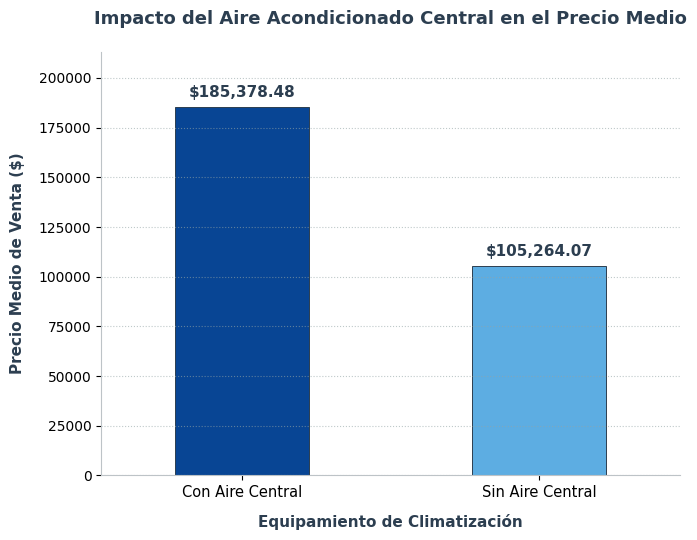

In [15]:
if 'CentralAir' in df_clean.columns and 'SalePrice' in df_clean.columns:
    
    # 1. Calculamos el precio medio de venta según si tiene o no Aire Acondicionado
    # Ordenamos de mayor a menor para que la barra más alta salga primero
    precio_por_aire = df_clean.groupby('CentralAir')['SalePrice'].mean().sort_values(ascending=False)

    # 2. Cambiamos el índice de texto ('Y', 'N') por etiquetas claras para el gráfico
    precio_por_aire.index = precio_por_aire.index.map({'Y': 'Con Aire Central', 'N': 'Sin Aire Central'})

    # 3. Configurar el lienzo con un tamaño estilizado
    plt.figure(figsize=(7, 5.5))

    # Definimos tus colores corporativos personalizados (Azul oscuro para Con Aire, Azul claro para Sin Aire)
    colores_barras = {'Con Aire Central': '#084594', 'Sin Aire Central': '#5dade2'}
    colores_lista = [colores_barras[estado] for estado in precio_por_aire.index]

    # 4. Dibujar las barras con los colores asignados y un ancho elegante
    precio_por_aire.plot(kind='bar', color=colores_lista, width=0.45, edgecolor='#2c3e50', linewidth=0.7)

    # 5. Configuración de títulos y etiquetas con fuentes limpias profesionales
    plt.title('Impacto del Aire Acondicionado Central en el Precio Medio', fontsize=13, pad=20, weight='bold', color='#2c3e50')
    plt.xlabel('Equipamiento de Climatización', fontsize=11, labelpad=10, weight='bold', color='#2c3e50')
    plt.ylabel('Precio Medio de Venta ($)', fontsize=11, labelpad=10, weight='bold', color='#2c3e50')

    # Ajustes de los ejes (quitar rotación molesta y limpiar bordes)
    plt.xticks(rotation=0, fontsize=10.5)
    plt.yticks(fontsize=10)
    
    # Le damos un margen del 15% arriba del valor máximo para que las etiquetas de texto queden holgadas
    plt.ylim(0, precio_por_aire.max() * 1.15) 

    # Añadir una rejilla horizontal muy sutil y elegante
    plt.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')

    # Ocultar las líneas del marco superior y derecho (estilo minimalista "despine")
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')

    # 6. Añadir los precios exactos formateados como moneda ($) encima de cada barra
    for i, v in enumerate(precio_por_aire):
        plt.text(
            i, 
            v + (precio_por_aire.max() * 0.02), # Desplazamiento dinámico hacia arriba
            f"${v:,.2f}", 
            ha='center', 
            va='bottom',
            fontweight='bold', 
            fontsize=11, 
            color='#2c3e50'
        )

    plt.tight_layout()
    plt.show()


## Análisis Exploratorio (EDA): Distribución de Densidad mediante Violin Plots

Estudio avanzado de la forma de la distribución, concentración y dispersión del precio de venta (`SalePrice`) cruzado con variables de confort. Los gráficos de violín combinan un diagrama de caja con un diagrama de densidad de kernel.

* **Variables analizadas:** `Fireplaces` (transformada a binaria `has_fireplace`) y `CentralAir`.
* **Configuración interna:** Marcado de cuartiles mediante líneas internas (`inner='quartile'`) para analizar asimetrías en las colas de precios altos.

C:\Users\felix\AppData\Local\Temp\ipykernel_26188\2880124458.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sí (Y)', 'No (N)'])


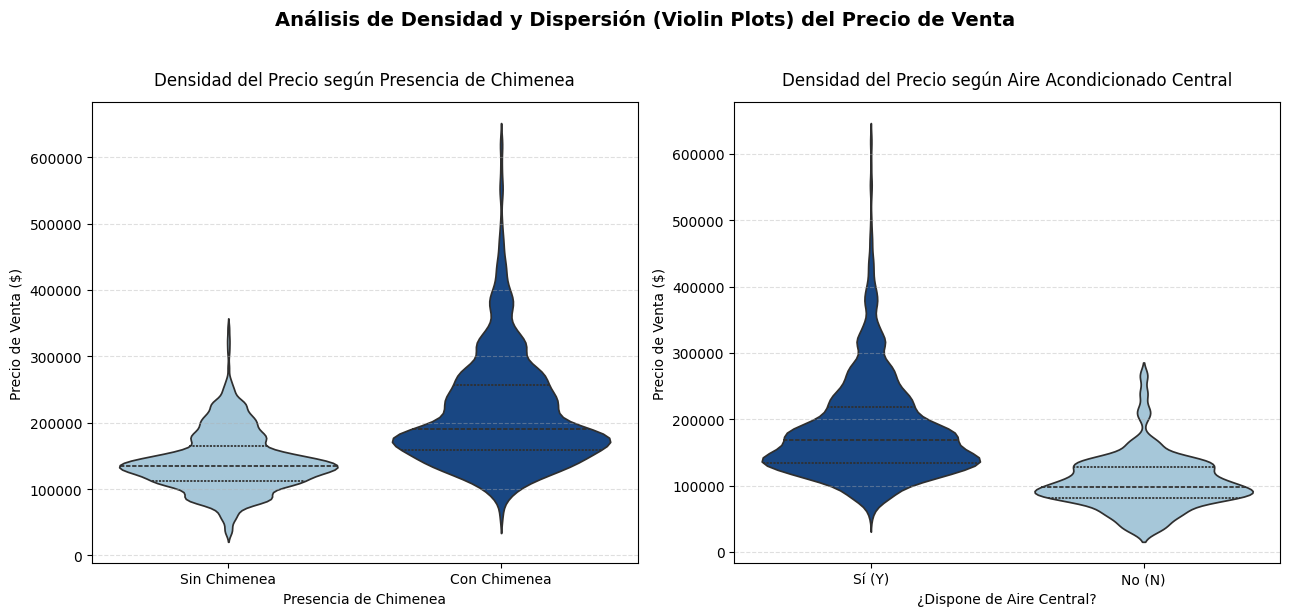

In [16]:
# Validamos que las columnas necesarias existan
if 'SalePrice' in df_clean.columns and 'Fireplaces' in df_clean.columns and 'CentralAir' in df_clean.columns:

    # Creamos una columna temporal binaria para el gráfico: ¿Tiene chimenea? (Sí / No)
    df_clean['has_fireplace'] = df_clean['Fireplaces'].apply(lambda x: 'Con Chimenea' if x > 0 else 'Sin Chimenea')

    # Creamos la estructura de 1 fila y 2 columnas con el tamaño ideal
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # Mapeamos tus colores corporativos: Azul oscuro para la opción premium, Azul claro para la básica
    colores_azul_1 = {'Con Chimenea': '#084594', 'Sin Chimenea': '#9ecae1'}
    colores_azul_2 = {'Y': '#084594', 'N': '#9ecae1'}

    # 1. Violin Plot para Chimeneas (Izquierda)
    sns.violinplot(
        ax=axes[0],
        data=df_clean,
        x='has_fireplace',
        y='SalePrice',
        palette=colores_azul_1,
        hue='has_fireplace', # Evita avisos en las versiones modernas de seaborn
        legend=False,
        inner='quartile',    # Dibuja las líneas de los cuartiles y la mediana dentro del violín
        bw_adjust=0.6        # Suaviza la curva para que se vea estilizada pero realista
    )
    axes[0].set_title('Densidad del Precio según Presencia de Chimenea', fontsize=12, pad=12)
    axes[0].set_xlabel('Presencia de Chimenea', fontsize=10)
    axes[0].set_ylabel('Precio de Venta ($)', fontsize=10)
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # 2. Violin Plot para Aire Acondicionado Central (Derecha)
    sns.violinplot(
        ax=axes[1],
        data=df_clean,
        x='CentralAir',
        y='SalePrice',
        palette=colores_azul_2,
        hue='CentralAir',
        legend=False,
        inner='quartile',    # Muestra las líneas discontinuas de los cuartiles internos
        bw_adjust=0.6
    )
    axes[1].set_title('Densidad del Precio según Aire Acondicionado Central', fontsize=12, pad=12)
    axes[1].set_xlabel('¿Dispone de Aire Central?', fontsize=10)
    axes[1].set_ylabel('Precio de Venta ($)', fontsize=10)
    axes[1].set_xticklabels(['Sí (Y)', 'No (N)'])
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    # Título principal del lienzo adaptado al negocio inmobiliario
    plt.suptitle('Análisis de Densidad y Dispersión (Violin Plots) del Precio de Venta', fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()

    # Muestra la ventana interactiva directamente en VS Code
    plt.show()

    # Eliminamos la columna temporal para dejar el dataset limpio
    df_clean.drop(columns=['has_fireplace'], inplace=True)


## Análisis Exploratorio (EDA): Evolución Histórica y Tendencias Temporales

Estudio del comportamiento del precio medio de las propiedades a lo largo del tiempo según su año de construcción (`YearBuilt`). Este enfoque nos permite identificar ciclos inmobiliarios, el impacto de la obsolescencia de los materiales y cómo influye la climatización como estándar de valor a lo largo de las décadas.

* **Variables analizadas:** `YearBuilt` (Línea de tiempo), `SalePrice` (Métrica) y `CentralAir` (Segmentación).
* **Objetivo:** Validar si la brecha de precio entre viviendas con y sin aire acondicionado central se mantiene constante o se amplía en las edificaciones más recientes.

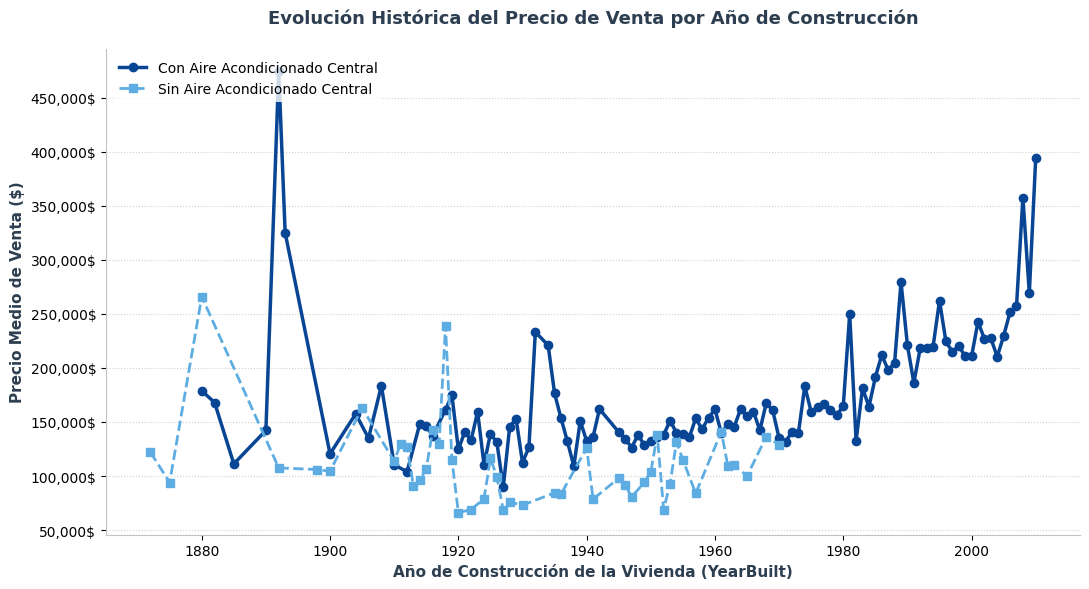

In [17]:
# Usamos el csv con los años de construcción y remodelación para analizar la evolución histórica del precio de venta
df_viviendas = pd.read_csv(r'data\Utiles\viviendas_procesadas\Viviendas_Procesadas_Modelos.csv')
# Validamos que las columnas clave existan en el DataFrame
if 'YearBuilt' in df_viviendas.columns and 'SalePrice' in df_viviendas.columns and 'CentralAir' in df_viviendas.columns:

    # --- 1. AGRUPACIÓN EVOLUTIVA POR AÑO DE CONSTRUCCIÓN Y AIRE ACONDICIONADO ---
    # Agrupamos por año de edificación y climatización para obtener el precio promedio de venta
    tendencia_casas = df_viviendas.groupby(['YearBuilt', 'CentralAir'])['SalePrice'].mean().reset_index()

    # Separamos en dos DataFrames limpios para trazar las líneas analíticas
    casas_con_aire = tendencia_casas[tendencia_casas['CentralAir'] == 'Y']
    casas_sin_aire = tendencia_casas[tendencia_casas['CentralAir'] == 'N']


    # --- 2. CONFIGURACIÓN DEL GRÁFICO MÚLTIPLE DE LÍNEAS TEMPORALES ---
    plt.figure(figsize=(11, 6))

    # --- LÍNEAS PARA CASAS PREMIUM (Con Aire - Tonos Azules Oscuros Corporativos) ---
    # Para evitar picos caóticos por años individuales con pocas casas, usamos un suavizado visual o marcadores limpios
    plt.plot(casas_con_aire['YearBuilt'], casas_con_aire['SalePrice'], 
             marker='o', linestyle='-', color='#084594', linewidth=2.5, label='Con Aire Acondicionado Central')

    # --- LÍNEAS PARA CASAS ESTÁNDAR (Sin Aire - Tonos Azules Claros) ---
    plt.plot(casas_sin_aire['YearBuilt'], casas_sin_aire['SalePrice'], 
             marker='s', linestyle='--', color='#5dade2', linewidth=2, label='Sin Aire Acondicionado Central')


    # --- 3. FORMATO ESTÉTICO Y MINIMALISTA PREMIUM ---
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Títulos y etiquetas ejecutivas para el reporte del grupo
    plt.title('Evolución Histórica del Precio de Venta por Año de Construcción', fontsize=13, pad=18, weight='bold', color='#2c3e50')
    plt.xlabel('Año de Construcción de la Vivienda (YearBuilt)', fontsize=11, weight='bold', color='#2c3e50')
    plt.ylabel('Precio Medio de Venta ($)', fontsize=11, weight='bold', color='#2c3e50')

    # Damos formato de dinero al eje vertical Y para que se entienda a la primera
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}$".format(int(x))))

    # Rejilla horizontal muy sutil para facilitar la lectura de precios
    plt.grid(axis='y', linestyle=':', alpha=0.5, color='#95a5a6')

    # Leyenda corporativa impecable
    plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper left')

    # Ocultar marcos sobrantes para estilo premium (Despine)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')

    plt.tight_layout()
    plt.show()


## Visualización Tridimensional del Plano de Regresión Múltiple

Introducción al modelado predictivo mediante la representación en un espacio de tres dimensiones ($3D$). Ajustamos un modelo lineal inicial utilizando las dos variables con mayor correlación con el target para construir geométricamente el plano de decisión.

* **Variables Independientes ($X_1, X_2$):** `GrLivArea` (Superficie) y `OverallQual` (Calidad Material).
* **Variable Objetivo ($Y$):** `SalePrice` (Precio de Venta).
* **Representación:** Los puntos azules representan las observaciones reales del dataset, mientras que la superficie translúcida roja  representa la función matemática predictiva ajustada por mínimos cuadrados.

# **Regresion**

In [18]:
print(df_clean.columns.tolist())

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 

In [19]:
#Aplicamos transformacion logaritmica
df_clean["SalePrice_Log"] = np.log1p(df_clean["SalePrice"])
# 1. Separamos nuestra variable objetivo (SalePrice_Log) y el Id 
# para que no se mezclen ni se alteren en la conversión
precios_log = df_clean['SalePrice_Log']
ids = df_clean['Id']

# Eliminamos las columnas de precio e Id de nuestra tabla de características
X = df_clean.drop(columns=['Id', 'SalePrice', 'SalePrice_Log'])

# 2. Aplicamos One-Hot Encoding automático a TODAS las columnas de texto
# drop_first=True evita la redundancia (si una casa no es de zona A ni B, por defecto es C)
X_codificado = pd.get_dummies(X, drop_first=True)

# 3. Comprobamos el impacto en las dimensiones
print("--- ⚙️ Proceso de Codificación Categórica Completado ---")
print(f"Dimensiones antes de codificar (variables originales): {X.shape[1]} columnas.")
print(f"Dimensiones después de codificar (One-Hot Encoding): {X_codificado.shape[1]} columnas.")

--- ⚙️ Proceso de Codificación Categórica Completado ---
Dimensiones antes de codificar (variables originales): 90 columnas.
Dimensiones después de codificar (One-Hot Encoding): 258 columnas.


In [20]:
# 1. DIVISIÓN EN ENTRENAMIENTO (80%) Y VALIDACIÓN (20%)
# Usamos un random_state fijo para que la división siempre sea idéntica
X_train, X_val, y_train, y_val = train_test_split(
    X_codificado, precios_log, test_size=0.2, random_state=42
)

# 2. IDENTIFICAR LAS COLUMNAS NUMÉRICAS CONTINUAS
# Solo queremos escalar las columnas que NO son binarias (las que no son de unos y ceros)
columnas_a_escalar = [col for col in X_train.columns if X_train[col].nunique() > 2]

# 3. CONFIGURAR EL ESCALADOR
scaler = StandardScaler()

# 4. AJUSTAR Y TRANSFORMAR LOS DATOS
# ¡Regla de oro!: El scaler SOLO aprende (fit) de X_train para evitar Fuga de Datos
X_train_escalado = X_train.copy()
X_val_escalado = X_val.copy()

X_train_escalado[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_val_escalado[columnas_a_escalar] = scaler.transform(X_val[columnas_a_escalar])

print("--- ⚖️ División y Escalamiento Completado ---")
print(f"Tamaño del set de Entrenamiento (X_train): {X_train_escalado.shape[0]} casas.")
print(f"Tamaño del set de Validación (X_val): {X_val_escalado.shape[0]} casas.")

--- ⚖️ División y Escalamiento Completado ---
Tamaño del set de Entrenamiento (X_train): 1164 casas.
Tamaño del set de Validación (X_val): 292 casas.


In [21]:
# 1. INSTANCIAR LOS CUATRO MODELOS DEL PROYECTO
modelo_ridge = Ridge(alpha=1.0)
modelo_lasso = Lasso(alpha=0.005, max_iter=10000)
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelo_xgb = XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42
)


# 2. FUNCIÓN REUTILIZABLE PARA EVALUAR CADA MODELO (Pasando a Dólares USD)
def evaluar_modelo(modelo, X_t, y_t, X_v, y_v):
    # Entrenar el modelo que le pasemos a la función
    modelo.fit(X_t, y_t)

    # Realizar predicciones en escala logarítmica
    p_train_log = modelo.predict(X_t)
    p_val_log = modelo.predict(X_v)

    # Transformación inversa con expm1 para regresar los valores a dólares reales
    y_t_usd = np.expm1(y_t)
    p_t_usd = np.expm1(p_train_log)
    y_v_usd = np.expm1(y_v)
    p_v_usd = np.expm1(p_val_log)

    # Calcular las métricas finales en dólares
    r2_t = r2_score(y_t_usd, p_t_usd)
    r2_v = r2_score(y_v_usd, p_v_usd)
    mae = mean_absolute_error(y_v_usd, p_v_usd)
    overfitting = (r2_t - r2_v) * 100

    # ¡Corregido aquí! Quitamos el carácter extraño
    return r2_t, r2_v, overfitting, mae


# 3. EJECUTAR EL ENTRENAMIENTO Y LA EVALUACIÓN EN CASOS INDEPENDIENTES

m_ridge = evaluar_modelo(
    modelo_ridge, X_train_escalado, y_train, X_val_escalado, y_val
)
m_lasso = evaluar_modelo(
    modelo_lasso, X_train_escalado, y_train, X_val_escalado, y_val
)
m_rf = evaluar_modelo(
    modelo_rf, X_train_escalado, y_train, X_val_escalado, y_val
)
m_xgb = evaluar_modelo(
    modelo_xgb, X_train_escalado, y_train, X_val_escalado, y_val
)


# 4. CONSTRUIR LA TABLA COMPARATIVA FINAL
tabla_completa = pd.DataFrame(
    {
        "Modelo": ["Ridge", "Lasso", "Random Forest", "XGBoost"],
        "R² Train": [m_ridge[0], m_lasso[0], m_rf[0], m_xgb[0]],
        "R² Validation": [m_ridge[1], m_lasso[1], m_rf[1], m_xgb[1]],
        "Brecha Overfitting": [
            f"{m_ridge[2]:.2f}%",
            f"{m_lasso[2]:.2f}%",
            f"{m_rf[2]:.2f}%",
            f"{m_xgb[2]:.2f}%",
        ],
        "MAE (Error En $)": [m_ridge[3], m_lasso[3], m_rf[3], m_xgb[3]],
    }
)

print("\n--- 🏁 ¡Torneo de Regresión Finalizado! ---")
display(tabla_completa.round(4))


--- 🏁 ¡Torneo de Regresión Finalizado! ---


,Modelo,R² Train,R² Validation,Brecha Overfitting,MAE (Error En $)
0,Ridge,0.9559,0.9240,3.19%,14115.1740
1,Lasso,0.9177,0.9092,0.85%,15562.4259
2,Random Forest,0.9782,0.8674,11.09%,18160.5003
3,XGBoost,0.9648,0.8975,6.74%,16263.4355


C:\Users\felix\AppData\Local\Temp\ipykernel_26188\2120743717.py:46: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=residuos_ridge, ax=ax_hist, color="crimson", fill=True, alpha=0.1, vertical=True, linewidth=1.5)


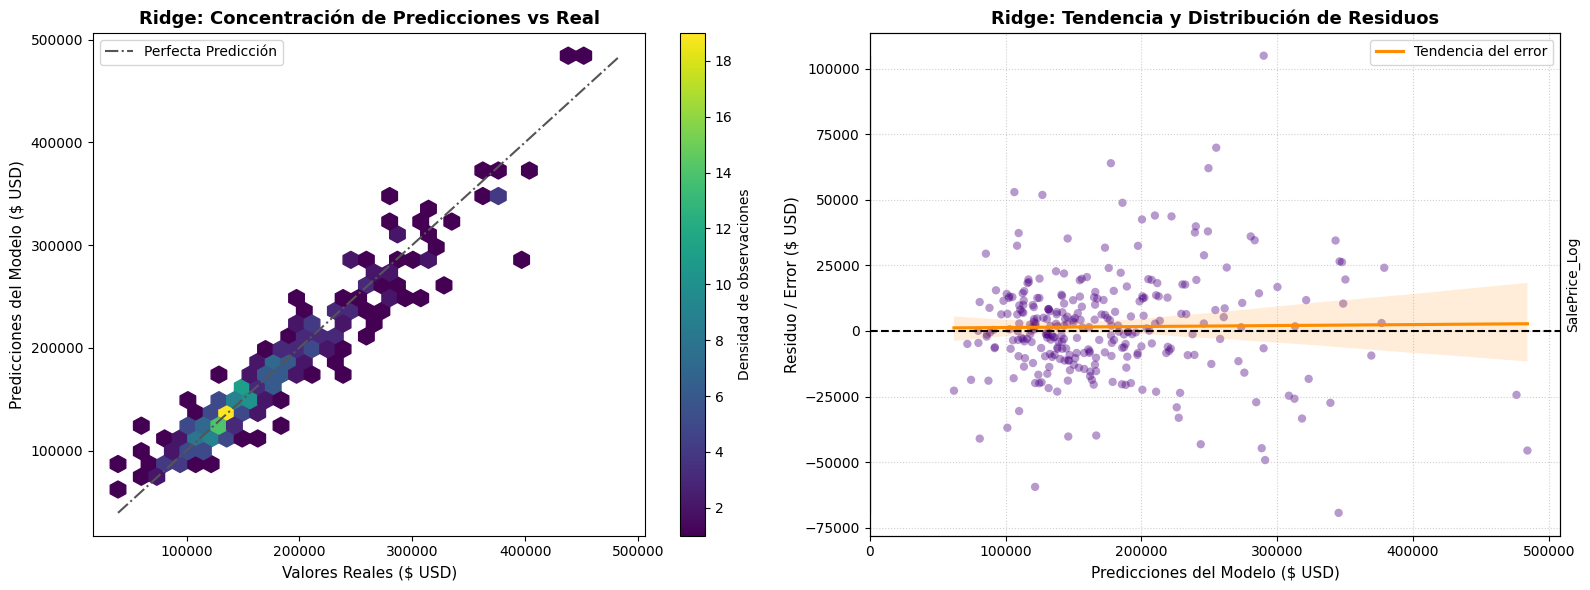

In [22]:
# 1. Volver a entrenar Ridge
modelo_ridge.fit(X_train_escalado, y_train)

# 2. Predicciones logarítmicas y reversión a dólares
pred_ridge_log = modelo_ridge.predict(X_val_escalado)
pred_ridge_usd = np.expm1(pred_ridge_log)
y_val_usd = np.expm1(y_val)

# 3. Residuos específicos
residuos_ridge = y_val_usd - pred_ridge_usd


# ==========================================================
# 4. NUEVA CONFIGURACIÓN DEL LIENZO VISUAL (Estilo Avanzado)
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: DENSIDAD HEXAGONAL (PREDICCIÓN VS REAL) ---
# Usamos hexbin para ver la densidad de puntos y evitar el sobre-solapamiento
hb = axes[0].hexbin(y_val_usd, pred_ridge_usd, gridsize=30, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Densidad de observaciones')

# Línea de referencia de 45 grados (en gris oscuro para no saturar)
limite_max = max(max(y_val_usd), max(pred_ridge_usd))
limite_min = min(min(y_val_usd), min(pred_ridge_usd))
axes[0].plot([limite_min, limite_max], [limite_min, limite_max], color="#555555", linestyle="-.", linewidth=1.5, label="Perfecta Predicción")

axes[0].set_title("Ridge: Concentración de Predicciones vs Real", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Valores Reales ($ USD)", fontsize=11)
axes[0].set_ylabel("Predicciones del Modelo ($ USD)", fontsize=11)
axes[0].legend(loc="upper left")


# --- GRÁFICO 2: RESIDUOS CON LÍNEA DE TENDENCIA e HISTOGRAMA INTEGRADO ---
# Dibujamos los puntos con un tono índigo suave
sns.scatterplot(ax=axes[1], x=pred_ridge_usd, y=residuos_ridge, alpha=0.4, color="indigo", edgecolor="none")

# Añadimos una línea de regresión local (tendencia del error) para ver si hay patrones ocultos
sns.regplot(ax=axes[1], x=pred_ridge_usd, y=residuos_ridge, scatter=False, color="darkorange", label="Tendencia del error")

# Línea base en el error cero
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1.5)

# Crear un segundo eje compartido para incrustar la distribución del residuo a la derecha
ax_hist = axes[1].twinx()
sns.kdeplot(data=residuos_ridge, ax=ax_hist, color="crimson", fill=True, alpha=0.1, vertical=True, linewidth=1.5)
ax_hist.set_yticks([]) # Ocultamos los ticks de probabilidad para no ensuciar

axes[1].set_title("Ridge: Tendencia y Distribución de Residuos", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicciones del Modelo ($ USD)", fontsize=11)
axes[1].set_ylabel("Residuo / Error ($ USD)", fontsize=11)
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
# Definimos las variables independientes (X) y la variable objetivo (y)
X_vars = df_clean[['GrLivArea', 'OverallQual']]
y_var = df_clean['SalePrice']

# Entrenamos un modelo rápido de Regresión Lineal para obtener la función matemática
modelo_3d = LinearRegression()
modelo_3d.fit(X_vars, y_var)

# Creamos una malla (grid) para generar la superficie suave de la función
x_space = np.linspace(df_clean['GrLivArea'].min(), df_clean['GrLivArea'].max(), 50)
y_space = np.linspace(df_clean['OverallQual'].min(), df_clean['OverallQual'].max(), 50)
X_mesh, Y_mesh = np.meshgrid(x_space, y_space)

# Evaluamos la función de regresión sobre la malla
Z_mesh = modelo_3d.predict(pd.DataFrame({
    'GrLivArea': X_mesh.ravel(),
    'OverallQual': Y_mesh.ravel()
})).reshape(X_mesh.shape)


# --- CONSTRUCCIÓN DEL GRÁFICO 3D AVANZADO (go.Figure) ---
fig = go.Figure()

# Añadimos los puntos reales del dataset (Dispersión)
# Eliminamos el degradado continuo sustituyéndolo por un color sólido corporativo fijo
fig.add_trace(go.Scatter3d(
    x=df_clean['GrLivArea'],
    y=df_clean['OverallQual'],
    z=df_clean['SalePrice'],
    mode='markers',
    marker=dict(
        size=4,
        color='#084594',                # Color azul oscuro sólido y profesional para todos los puntos
        opacity=0.85
    ),
    name='Casas Reales',
    text=[f"Barrio: {n}" for n in df_clean['Neighborhood']] 
))

# Añadimos la SUPERFICIE DE REGRESIÓN (La función matemática calculada)
# Modificamos la superficie a un único color plano translúcido sin degradados de escala
fig.add_trace(go.Surface(
    x=x_space,
    y=y_space,
    z=Z_mesh,
    colorscale=[[0, '#e74c3c'], [1, '#e74c3c']], # Fuerza un color rojo plano uniforme en toda la sábana
    opacity=0.4,
    name='Plano de Predicción (Regresión)',
    showscale=False
))

# Personalización ejecutiva del lienzo tridimensional
fig.update_layout(
    title=dict(
        text="<b>Plano de Predicción Tridimensional (Función de Regresión)</b>",
        x=0.5,
        font=dict(size=16, color='#2c3e50')
    ),
    scene=dict(
        xaxis_title='Superficie Habitable (GrLivArea)',
        yaxis_title='Calidad General (OverallQual)',
        zaxis_title='Precio de Venta ($)',
        xaxis=dict(backgroundcolor="#f8f9f9", gridcolor="white", showbackground=True, zerolinecolor="white"),
        yaxis=dict(backgroundcolor="#f8f9f9", gridcolor="white", showbackground=True, zerolinecolor="white"),
        zaxis=dict(backgroundcolor="#f8f9f9", gridcolor="white", showbackground=True, zerolinecolor="white")
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(x=0, y=1)
)

# Forzamos a Plotly a abrirlo de manera interactiva en tu navegador predeterminado
pio.renderers.default = "browser"
fig.show()

In [24]:
# Definir la ruta de destino y asegurar que existan las carpetas
ruta_destino = os.path.join("data", "utiles", "modelo")
os.makedirs(ruta_destino, exist_ok=True)

# Guardar el modelo ganador (Ridge)
joblib.dump(modelo_ridge, os.path.join(ruta_destino, "modelo_ridge_house_prices.pkl"))

# Guardar el escalador (¡Vital para que Streamlit transforme los números igual que en Train!)
joblib.dump(scaler, os.path.join(ruta_destino, "escalador_house_prices.pkl"))

# Guardar la lista de columnas que espera el modelo tras el One-Hot Encoding
columnas_modelo = list(X_codificado.columns)
joblib.dump(columnas_modelo, os.path.join(ruta_destino, "columnas_modelo.pkl"))

print(f"💾 ¡Archivos exportados con éxito (.pkl) en la ruta: {ruta_destino}!")

💾 ¡Archivos exportados con éxito (.pkl) en la ruta: data\utiles\modelo!
